# 04 Geospatial Exposure Features

## Goal

This notebook creates the first geospatial exposure features for the project.

The previous notebook created a spatial asset layer containing 3,058 operational renewable energy assets represented as map points.

This notebook asks:

1. Where are the assets located?
2. How are they distributed by region?
3. Can we create a first-pass geographic exposure proxy?
4. Which assets may warrant closer review?

This is still a Version 1 screening model. The exposure feature created here is a proxy, not a formal flood, heat or coastal hazard layer.

In [46]:
from pathlib import Path

import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path("..").resolve()

DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
OUTPUTS = PROJECT_ROOT / "outputs"
FIGURES = OUTPUTS / "figures"
TABLES = OUTPUTS / "tables"

FIGURES.mkdir(parents=True, exist_ok=True)
TABLES.mkdir(parents=True, exist_ok=True)

assets_path = DATA_PROCESSED / "operational_energy_assets_27700.geojson"

assets_gdf = gpd.read_file(assets_path)

print("Rows:", len(assets_gdf))
print("CRS:", assets_gdf.crs)
assets_gdf.head()

Rows: 3058
CRS: EPSG:27700


,Ref ID,Operator (or Applicant),Site Name,Technology Type,Installed Capacity (MWelec),Development Status,Development Status (short),County,Region,Country,Post Code,X-coordinate,Y-coordinate,Planning Authority,Under Construction,Operational,Solar Site Area (sqm),development_status_clean,geometry
0,3,Scottish and Southern Energy (SSE),Ferrybridge Multifuel 2 (FM2),EfW Incineration,70.0,Operational,Operational,West Yorkshire,Yorkshire and Humber,England,NaN,447490,424684,The Planning Inspectorate - National Infrastru...,01/09/2016,20/12/2019,NaN,operational,POINT (447490 424684)
1,4,Energy Power Resources,Thetford Biomass Power Station,Biomass (dedicated),38.5,Operational,Operational,Norfolk,Eastern,England,NaN,585300,286900,Breckland,NaN,02/10/1998,NaN,operational,POINT (585300 286900)
2,14,Dalkia,Chilton Energy Plant,Biomass (dedicated),18.0,Operational,Operational,County Durham,North East,England,NaN,428049,530414,County Durham,01/03/2010,12/03/2012,NaN,operational,POINT (428049 530414)
3,22,Double H Nurseries,Double H Nurseries Biomass Plant,Biomass (dedicated),1.5,Operational,Operational,Hampshire,South East,England,BH25 5NQ,422804,94625,New Forest,NaN,15/12/2012,NaN,operational,POINT (422804 94625)
4,23,REACT Energy (Kedco),Newry Biomass Phase 1 (Gasification),Advanced Conversion Technologies,2.0,Operational,Operational,Co. Down,Northern Ireland,Northern Ireland,NaN,117392,488885,"Newry, Mourne and Down",NaN,27/06/2012,NaN,operational,POINT (117392 488885)


## Regional distribution

Before creating exposure features, I first summarise the asset dataset by region.

This gives a basic view of where operational renewable energy assets are concentrated.

Regional summaries are useful because exposure analysis is often interpreted at more than one level:

- individual asset level,
- regional level,
- portfolio level.

In [47]:
regional_summary = (
    assets_gdf
    .groupby("Region")
    .agg(
        asset_count=("Ref ID", "count"),
        total_capacity_mw=("Installed Capacity (MWelec)", "sum"),
        mean_capacity_mw=("Installed Capacity (MWelec)", "mean")
    )
    .reset_index()
    .sort_values("asset_count", ascending=False)
)

regional_summary

,Region,asset_count,total_capacity_mw,mean_capacity_mw
7,Scotland,565,12382.83,22.311405
9,South West,529,3907.90,7.500768
1,Eastern,326,3378.04,10.490807
8,South East,312,3468.95,11.226375
0,East Midlands,268,2010.06,7.585132
10,Wales,243,4549.00,19.033473
4,North West,194,1572.56,8.147979
12,Yorkshire and Humber,167,4408.32,26.717091
11,West Midlands,145,1309.11,9.486304
5,Northern Ireland,118,1453.50,12.317797


In [48]:
regional_summary.to_csv(
    TABLES / "regional_asset_summary.csv",
    index=False
)

print("Saved regional summary to:", TABLES / "regional_asset_summary.csv")

Saved regional summary to: /Users/oconnor/jaurice-market-notes/projects/physical-climate-risk-uk-energy/outputs/tables/regional_asset_summary.csv


## Creating a first-pass exposure proxy

A full physical climate risk model would ideally use dedicated hazard data, such as flood zones, heat stress layers, coastal erosion data or climate scenario rasters.

This Version 1 project does not yet use formal hazard layers. Instead, it creates a simple distance-based geographic proxy to demonstrate the exposure-screening workflow.

The proxy asks:

> How close is each asset to the edge of the asset geography?

This should not be interpreted as a true flood, heat or coastal hazard score. It is a placeholder feature used to learn the geospatial method.

In a stronger version, this proxy would be replaced with formal hazard layers.

In [49]:
# Create a combined boundary from the asset distribution area
# This creates a broad convex hull around all operational assets.
asset_area = assets_gdf.unary_union.convex_hull

asset_boundary = asset_area.boundary

print("Asset area type:", asset_area.geom_type)
print("Boundary type:", asset_boundary.geom_type)

Asset area type: Polygon
Boundary type: LineString


/var/folders/n0/d6hc7dkn4qq945r580z9xnlm0000gn/T/ipykernel_3295/889617951.py:3: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  asset_area = assets_gdf.unary_union.convex_hull


## Distance to boundary proxy

The next step calculates the distance from each asset to the boundary proxy.

Because the asset layer uses `EPSG:27700`, distances are measured in metres.

This creates a new field:

`distance_to_boundary_m`

This field measures how far each asset is from the boundary proxy in metres.

In [50]:
assets_exposure = assets_gdf.copy()

assets_exposure["distance_to_boundary_m"] = assets_exposure.geometry.distance(asset_boundary)

assets_exposure[[
    "Site Name",
    "Technology Type",
    "Region",
    "Installed Capacity (MWelec)",
    "distance_to_boundary_m"
]].head()

,Site Name,Technology Type,Region,Installed Capacity (MWelec),distance_to_boundary_m
0,Ferrybridge Multifuel 2 (FM2),EfW Incineration,Yorkshire and Humber,70.0,191191.372956
1,Thetford Biomass Power Station,Biomass (dedicated),Eastern,38.5,90187.542957
2,Chilton Energy Plant,Biomass (dedicated),North East,18.0,184875.461233
3,Double H Nurseries Biomass Plant,Biomass (dedicated),South East,1.5,29462.766557
4,Newry Biomass Phase 1 (Gasification),Advanced Conversion Technologies,Northern Ireland,2.0,99471.331514


## Creating proximity flags

To make the distance feature easier to interpret, I create two simple proximity flags:

- `within_5km_boundary_proxy`
- `within_10km_boundary_proxy`

These flags identify assets that are relatively close to the boundary proxy.

Again, these are not formal hazard indicators. They are first-pass screening features that demonstrate how distance-based exposure variables can be created.

In [51]:
assets_exposure["within_5km_boundary_proxy"] = (
    assets_exposure["distance_to_boundary_m"] <= 5_000
)

assets_exposure["within_10km_boundary_proxy"] = (
    assets_exposure["distance_to_boundary_m"] <= 10_000
)

assets_exposure[[
    "Site Name",
    "Region",
    "distance_to_boundary_m",
    "within_5km_boundary_proxy",
    "within_10km_boundary_proxy"
]].head()

,Site Name,Region,distance_to_boundary_m,within_5km_boundary_proxy,within_10km_boundary_proxy
0,Ferrybridge Multifuel 2 (FM2),Yorkshire and Humber,191191.372956,False,False
1,Thetford Biomass Power Station,Eastern,90187.542957,False,False
2,Chilton Energy Plant,North East,184875.461233,False,False
3,Double H Nurseries Biomass Plant,South East,29462.766557,False,False
4,Newry Biomass Phase 1 (Gasification),Northern Ireland,99471.331514,False,False


In [52]:
proximity_summary = pd.DataFrame({
    "metric": [
        "Total assets",
        "Assets within 5km boundary proxy",
        "Assets within 10km boundary proxy"
    ],
    "count": [
        len(assets_exposure),
        assets_exposure["within_5km_boundary_proxy"].sum(),
        assets_exposure["within_10km_boundary_proxy"].sum()
    ]
})

proximity_summary

,metric,count
0,Total assets,3058
1,Assets within 5km boundary proxy,24
2,Assets within 10km boundary proxy,45


## Visual check of the boundary proxy

This plot shows the asset points and the boundary proxy.

The purpose is to check that the distance feature has been calculated against a sensible geometry.

This is still an analytical prototype, not a final climate hazard map.

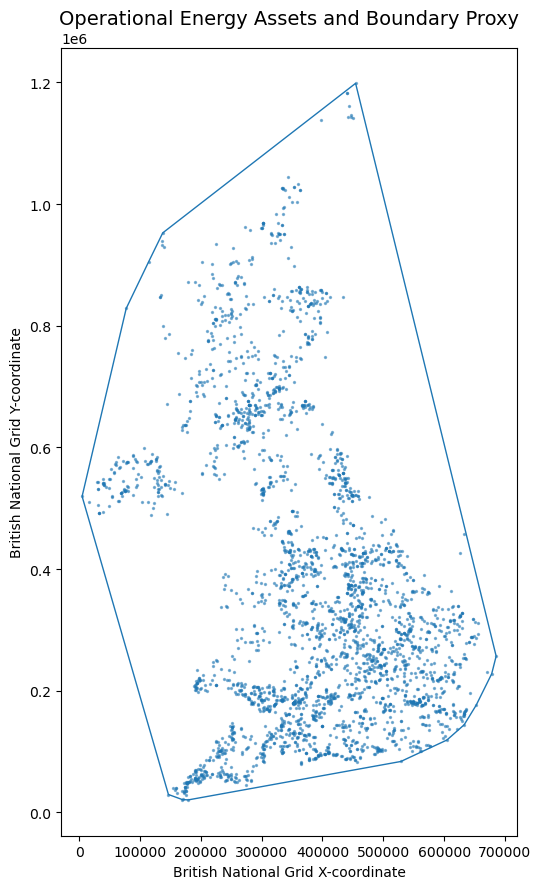

Saved figure to: /Users/oconnor/jaurice-market-notes/projects/physical-climate-risk-uk-energy/outputs/figures/asset_boundary_proxy_map.png


In [53]:
fig, ax = plt.subplots(figsize=(8, 9))

assets_exposure.plot(
    ax=ax,
    markersize=2,
    alpha=0.5
)

gpd.GeoSeries([asset_boundary], crs=assets_exposure.crs).plot(
    ax=ax,
    linewidth=1
)

ax.set_title("Operational Energy Assets and Boundary Proxy", fontsize=14)
ax.set_xlabel("British National Grid X-coordinate")
ax.set_ylabel("British National Grid Y-coordinate")

plt.tight_layout()

figure_path = FIGURES / "asset_boundary_proxy_map.png"
plt.savefig(figure_path, dpi=200)

plt.show()

print("Saved figure to:", figure_path)

## Saving exposure features

The exposure-enhanced asset layer is saved to the processed data folder.

This output contains the original cleaned asset information plus the first-pass geospatial exposure features.

The next notebook will use these fields to create a transparent preliminary exposure score.

In [54]:
exposure_path = DATA_PROCESSED / "operational_energy_assets_exposure_features.geojson"

assets_exposure.to_file(exposure_path, driver="GeoJSON")

print("Saved exposure feature layer to:")
print(exposure_path)

Saved exposure feature layer to:
/Users/oconnor/jaurice-market-notes/projects/physical-climate-risk-uk-energy/data/processed/operational_energy_assets_exposure_features.geojson


In [55]:
check = gpd.read_file(exposure_path)

print("Rows:", len(check))
print("CRS:", check.crs)
print(check.columns.tolist())

check.head()

Rows: 3058
CRS: EPSG:27700
['Ref ID', 'Operator (or Applicant)', 'Site Name', 'Technology Type', 'Installed Capacity (MWelec)', 'Development Status', 'Development Status (short)', 'County', 'Region', 'Country', 'Post Code', 'X-coordinate', 'Y-coordinate', 'Planning Authority', 'Under Construction', 'Operational', 'Solar Site Area (sqm)', 'development_status_clean', 'distance_to_boundary_m', 'within_5km_boundary_proxy', 'within_10km_boundary_proxy', 'geometry']


,Ref ID,Operator (or Applicant),Site Name,Technology Type,Installed Capacity (MWelec),Development Status,Development Status (short),County,Region,Country,...,Y-coordinate,Planning Authority,Under Construction,Operational,Solar Site Area (sqm),development_status_clean,distance_to_boundary_m,within_5km_boundary_proxy,within_10km_boundary_proxy,geometry
0,3,Scottish and Southern Energy (SSE),Ferrybridge Multifuel 2 (FM2),EfW Incineration,70.0,Operational,Operational,West Yorkshire,Yorkshire and Humber,England,...,424684,The Planning Inspectorate - National Infrastru...,01/09/2016,20/12/2019,NaN,operational,191191.372956,False,False,POINT (447490 424684)
1,4,Energy Power Resources,Thetford Biomass Power Station,Biomass (dedicated),38.5,Operational,Operational,Norfolk,Eastern,England,...,286900,Breckland,NaN,02/10/1998,NaN,operational,90187.542957,False,False,POINT (585300 286900)
2,14,Dalkia,Chilton Energy Plant,Biomass (dedicated),18.0,Operational,Operational,County Durham,North East,England,...,530414,County Durham,01/03/2010,12/03/2012,NaN,operational,184875.461233,False,False,POINT (428049 530414)
3,22,Double H Nurseries,Double H Nurseries Biomass Plant,Biomass (dedicated),1.5,Operational,Operational,Hampshire,South East,England,...,94625,New Forest,NaN,15/12/2012,NaN,operational,29462.766557,False,False,POINT (422804 94625)
4,23,REACT Energy (Kedco),Newry Biomass Phase 1 (Gasification),Advanced Conversion Technologies,2.0,Operational,Operational,Co. Down,Northern Ireland,Northern Ireland,...,488885,"Newry, Mourne and Down",NaN,27/06/2012,NaN,operational,99471.331514,False,False,POINT (117392 488885)
